# 06 — Explainability and Serving

All numbers loaded from JSON; no ML computation in this notebook.

In [1]:
import json
from pathlib import Path

EXPLAIN = Path("../reports/explain")
FIGURES = Path("../reports/figures/explain")
RANKER  = Path("../reports/ranker")

shap = json.loads((EXPLAIN / "shap_summary.json").read_text())
examples = json.loads((EXPLAIN / "examples.json").read_text())
abl = json.loads((RANKER / "ablations.json").read_text())

try:
    bench = json.loads((EXPLAIN / "serving_benchmark.json").read_text())
except FileNotFoundError:
    bench = {}

print("SHAP summary loaded:", list(shap.keys()))
print("Examples:", len(examples))


SHAP summary loaded: ['n_customers_sampled', 'n_rows_sampled', 'n_top12_rows', 'additivity', 'top10_shap_all_candidates', 'top10_shap_top12_rows', 'top10_contrast_shap_all_candidates', 'top10_contrast_shap_top12_rows', 'top10_gain_importance', 'shap_vs_gain_disagreements', 'group_shap_all_candidates', 'group_contrast_shap_all_candidates', 'group_shap_top12', 'ablation_deltas', 'segment_comparison', 'faithfulness', 'reasons_coverage', 'reason_quality_check', 'runtime_s']
Examples: 5


## A — SHAP Correctness (Additivity)

LightGBM exact TreeSHAP (pred_contrib=True).\n**Additivity invariant:** Σ SHAP + expected_value = model_score for every row.

In [2]:
n_cust  = shap["n_customers_sampled"]
n_rows  = shap["n_rows_sampled"]
n_top12 = shap["n_top12_rows"]
add_all  = shap["additivity"]["all_candidates"]
add_top  = shap["additivity"]["top12_rows"]

print(f"Customers sampled (seed 42): {n_cust:,}")
print(f"Total candidate rows:         {n_rows:,}")
print(f"Top-12 rows:                  {n_top12:,}")
print()
print(f"Additivity check — all candidates:")
print(f"  max_error = {add_all['max_error']:.2e}  (tol 1e-5)  passed={add_all['passed']}")
print(f"Additivity check — top-12 rows:")
print(f"  max_error = {add_top['max_error']:.2e}  (tol 1e-5)  passed={add_top['passed']}")


Customers sampled (seed 42): 5,000
Total candidate rows:         1,000,000
Top-12 rows:                  60,000

Additivity check — all candidates:
  max_error = 3.94e-07  (tol 1e-5)  passed=True
Additivity check — top-12 rows:
  max_error = 3.04e-07  (tol 1e-5)  passed=True


## B — Global Feature Importance

Mean |SHAP| per feature on all candidates and on top-12 recommended rows. Compared with Session 4 gain importance top-10.

In [3]:
print(f"{'Rank':>4s}  {'Feature':<42s}  {'|SHAP| (all)':>13s}  {'|contrast| (all)':>18s}  {'Gain rank':>10s}")
print("-" * 100)
gain_top10 = shap["top10_gain_importance"]
contrast_all_map = {r["feature"]: r["mean_abs_contrast_shap"]
                    for r in shap.get("top10_contrast_shap_all_candidates", [])}
for rank, row in enumerate(shap["top10_shap_all_candidates"], 1):
    f = row["feature"]
    v_all = row["mean_abs_shap"]
    cv = contrast_all_map.get(f, 0.0)
    gr = gain_top10.index(f) + 1 if f in gain_top10 else ">10"
    marker = "" if f in gain_top10 else "  ← ranked lower by gain"
    print(f"  {rank:>2d}  {f:<42s}  {v_all:>13.6f}  {cv:>18.6f}  {str(gr):>10s}{marker}")

print()
print("Ranking-relevant view — top-10 by mean |contrast SHAP|:")
print(f"  {'Rank':>4s}  {'Feature':<42s}  {'|contrast| (all)':>18s}  {'|contrast| (top-12)':>20s}")
contrast_top12_map = {r["feature"]: r["mean_abs_contrast_shap"]
                      for r in shap.get("top10_contrast_shap_top12_rows", [])}
for rank, row in enumerate(shap.get("top10_contrast_shap_all_candidates", [])[:10], 1):
    f = row["feature"]
    cv_all = row["mean_abs_contrast_shap"]
    cv_top12 = contrast_top12_map.get(f, 0.0)
    print(f"  {rank:>2d}  {f:<42s}  {cv_all:>18.6f}  {cv_top12:>20.6f}")


Rank  Feature                                      |SHAP| (all)    |contrast| (all)   Gain rank
----------------------------------------------------------------------------------------------------
   1  a_sales_1w                                       0.310538            0.280885           4
   2  a_days_since_last_sale                           0.182843            0.169694         >10  ← ranked lower by gain
   3  i_channel_gap                                    0.156242            0.129077           9
   4  i_days_since_bought_product_code                 0.112908            0.090054           1
   5  i_age_gap                                        0.097592            0.000000         >10  ← ranked lower by gain
   6  i_price_ratio                                    0.089027            0.078645         >10  ← ranked lower by gain
   7  i_customer_share_garment_group                   0.086846            0.079144         >10  ← ranked lower by gain
   8  a_section_name               

**Raw |SHAP| vs ranking-relevant |contrast SHAP|.**
Customer-level features (c_age, c_n_purchases, etc.) have high raw |SHAP| because they
shift *all* of a customer's candidate scores by the same amount. This does not help the
model choose *between* items for the same customer. The within-list contrast view
removes this common offset: contrast_i = SHAP_i − mean(SHAP across customer's candidates).
Features with high |contrast SHAP| are the ones that actually drive the item ranking
within a customer's pool. This is the view most relevant to explaining why item A
is recommended over item B.

Gain importance inflates high-cardinality categoricals (a_section_name, a_colour_group_name)
because they generate more splits; their SHAP and contrast magnitudes give a more faithful
signal. Features ranked lower by gain but appearing in the SHAP/contrast top-10 are
surfaced by attribution, not by split frequency.


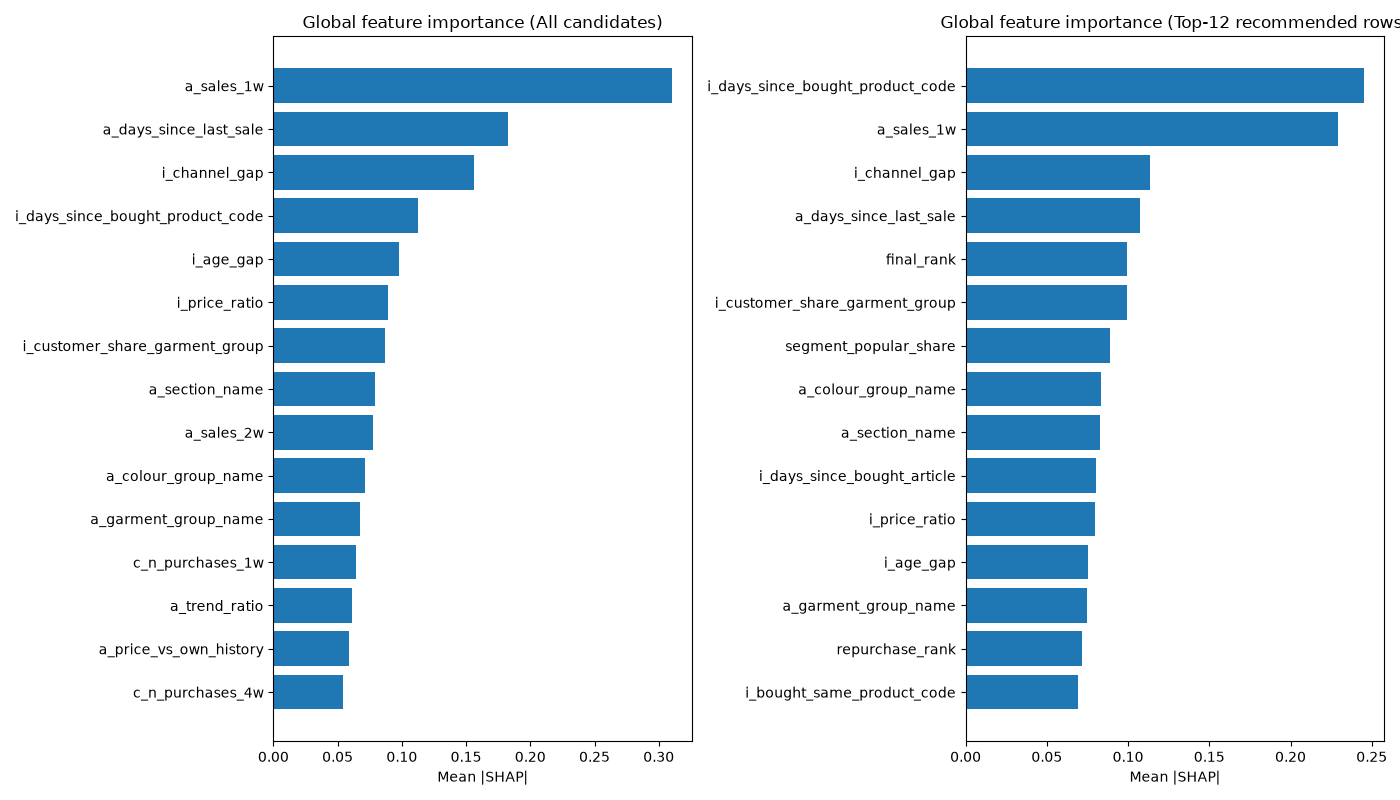

In [4]:
from IPython.display import Image
import os
fig = FIGURES / "shap_global_importance.png"
if fig.exists():
    display(Image(str(fig)))
else:
    print("Figure not found:", fig)


### B.2 Group SHAP vs Ablation Deltas

Sum of mean |SHAP| per feature group vs MAP@12 drop when the group is removed.

In [5]:
print(f"{'Group':<15s}  {'|SHAP| sum':>12s}  {'|contrast| sum':>16s}  {'Ablation delta':>15s}")
print("-" * 65)
for grp in ["article", "interaction", "customer", "candidate"]:
    sv  = shap["group_shap_all_candidates"].get(grp, 0.0)
    cv  = shap.get("group_contrast_shap_all_candidates", {}).get(grp, 0.0)
    ad  = shap["ablation_deltas"].get(grp, float("nan"))
    print(f"  {grp:<13s}  {sv:>12.6f}  {cv:>16.6f}  {ad:>+15.6f}")
print()
cust_sv = shap["group_shap_all_candidates"]["customer"]
cand_sv = shap["group_shap_all_candidates"]["candidate"]
cust_cv = shap.get("group_contrast_shap_all_candidates", {}).get("customer", float("nan"))
print(f"customer: raw |SHAP| = {cust_sv:.3f} ≈ candidate ({cand_sv:.3f}), but contrast |SHAP| is much lower ({cust_cv:.3f}).")
print("Customer features shift all candidates' scores equally → low ranking contribution.")
print("Correlated features share SHAP credit, so a group can have high SHAP but low ablation cost.")


Group              |SHAP| sum    |contrast| sum   Ablation delta
-----------------------------------------------------------------
  article            1.173882          1.105062        -0.002372
  interaction        0.654882          0.534582        -0.001886
  customer           0.305822          0.165872        -0.000688
  candidate          0.306728          0.291029        -0.000466

customer: raw |SHAP| = 0.306 ≈ candidate (0.307), but contrast |SHAP| is much lower (0.166).
Customer features shift all candidates' scores equally → low ranking contribution.
Correlated features share SHAP credit, so a group can have high SHAP but low ablation cost.


### B.3 Dependence Plots (top 5 features)

SHAP value vs feature value, colored by the most correlated second feature.

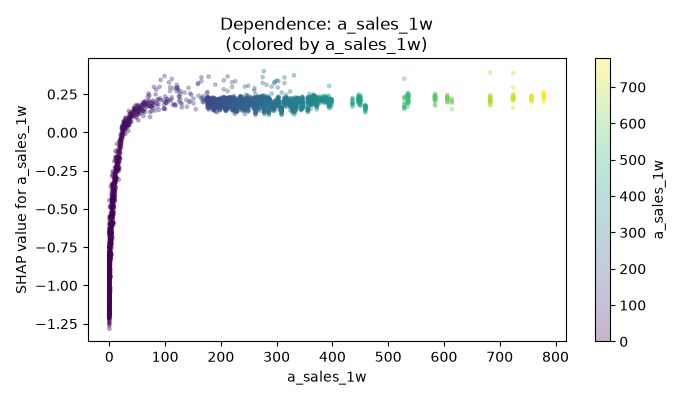

Feature: a_sales_1w


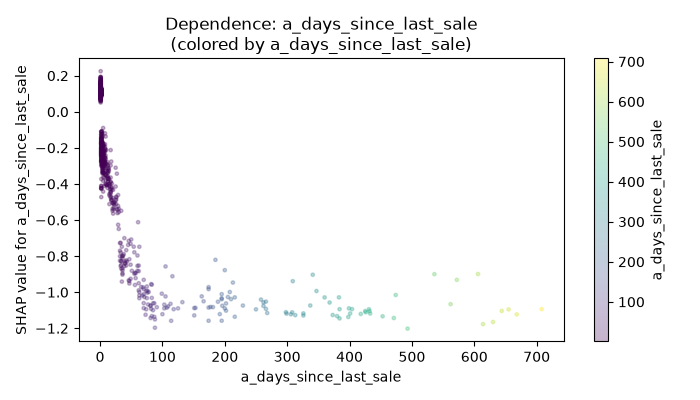

Feature: a_days_since_last_sale


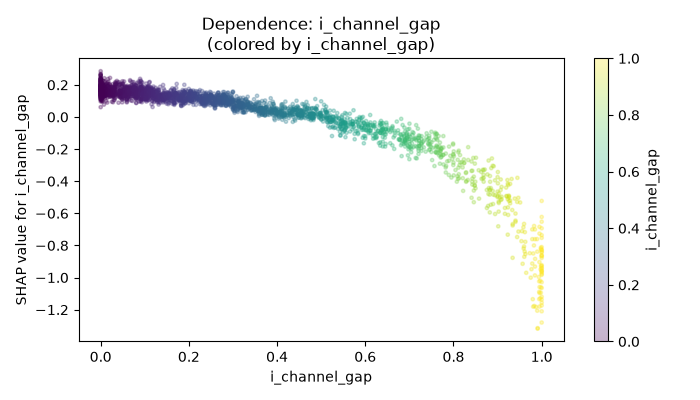

Feature: i_channel_gap


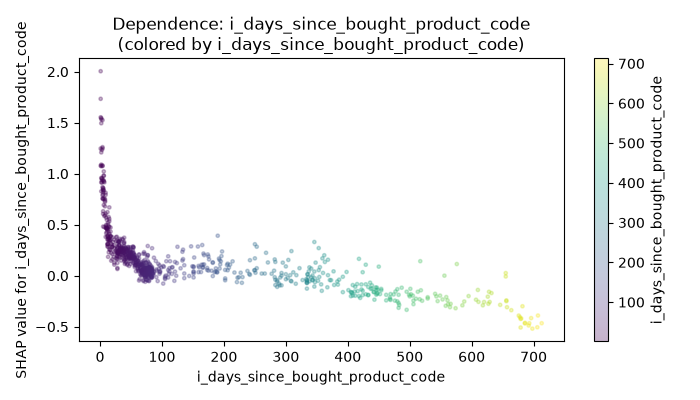

Feature: i_days_since_bought_product_code


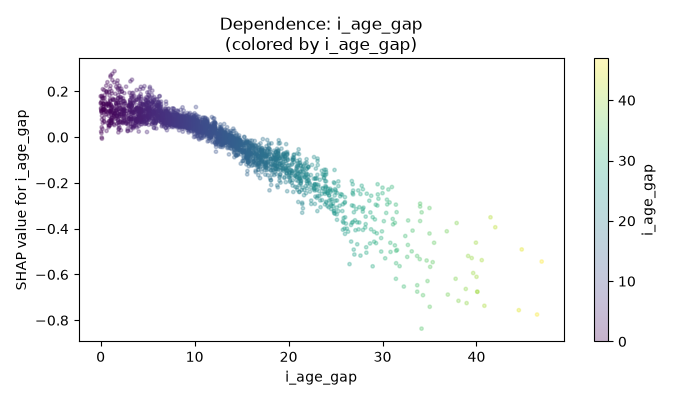

Feature: i_age_gap


In [6]:
from IPython.display import Image
import os
top5 = [r["feature"] for r in shap["top10_shap_all_candidates"][:5]]
for i, feat in enumerate(top5, 1):
    # Try to find the plot file
    matches = list(FIGURES.glob(f"shap_dep_{i:02d}_*.png"))
    if matches:
        display(Image(str(matches[0])))
        print(f"Feature: {feat}")
    else:
        print(f"Plot not found for feature {feat}")


### B.4 Segment SHAP: Cold-Start vs 20+ Buyers

Cold-start (n=69,000) vs Heavy buyers 20+ (n=667,000)

Feature                                       Cold-start   Heavy (20+)
----------------------------------------------------------------------
  a_sales_1w                                    0.215972      0.348775
  a_days_since_last_sale                        0.129092      0.207287
  i_days_since_bought_product_code              0.082583      0.118796
  c_n_purchases_1w                              0.065235      0.000000
  c_n_purchases_4w                              0.053922      0.000000
  a_colour_group_name                           0.050910      0.075014
  a_garment_group_name                          0.050245      0.000000
  i_age_gap                                     0.044500      0.098331
  segment_popular_share                         0.044477      0.000000
  final_rank                                    0.043996      0.000000
  i_channel_gap                                 0.000000      0.160431
  i_price_ratio       

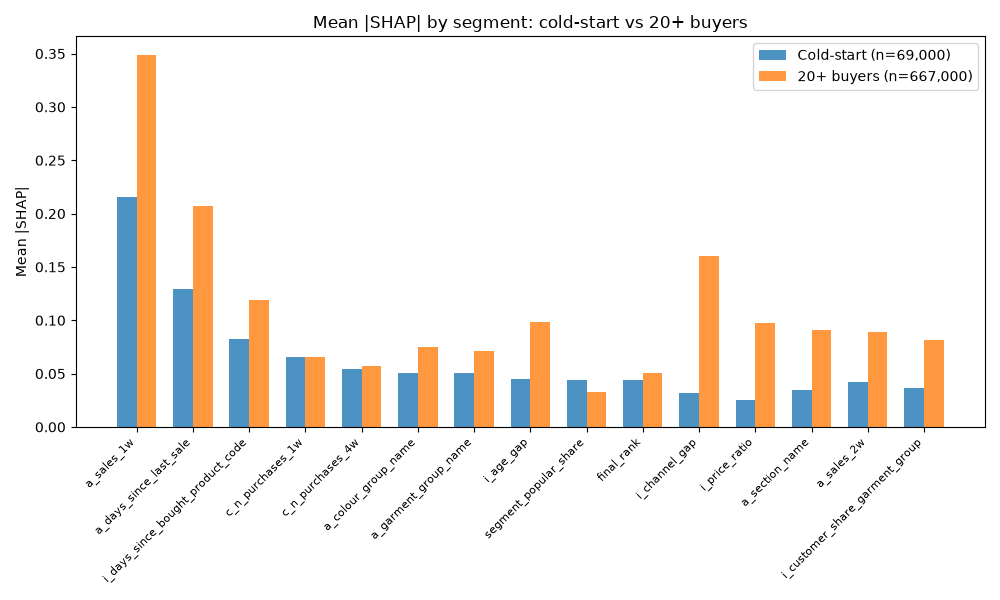

In [7]:
cold = shap["segment_comparison"]["cold_start"]
heavy = shap["segment_comparison"]["heavy_buyer_20plus"]
print(f"Cold-start (n={cold['n']:,}) vs Heavy buyers 20+ (n={heavy['n']:,})")
print()
print(f"{'Feature':<42s}  {'Cold-start':>12s}  {'Heavy (20+)':>12s}")
print("-" * 70)
cold_map = {r["feature"]: r["mean_abs_shap"] for r in cold["top10"]}
heavy_map = {r["feature"]: r["mean_abs_shap"] for r in heavy["top10"]}
all_feats = list(dict.fromkeys(
    [r["feature"] for r in cold["top10"]] + [r["feature"] for r in heavy["top10"]]
))
for f in all_feats:
    cv = cold_map.get(f, 0.0)
    hv = heavy_map.get(f, 0.0)
    print(f"  {f:<40s}  {cv:>12.6f}  {hv:>12.6f}")

from IPython.display import Image
seg_fig = FIGURES / "shap_segment_comparison.png"
if seg_fig.exists():
    display(Image(str(seg_fig)))


## C — Within-List Contrast and Reason Codes

LambdaRank scores are only meaningful within a customer's candidate list. We define each item's explanation as its SHAP vector minus the mean SHAP vector over that customer's candidates:\n\n    contrast_i = SHAP_i  −  mean(SHAP over all candidates for this customer)\n\nOnly features with **positive** contrast count as reasons: the item must be above the customer's within-list average for that feature.\n\n**Reason rules:** (1) exact-item reason suppresses product-code reason for the same item; (2) category share threshold — ≥25%: 'you buy often', 10-25%: 'you've bought from before', <10%: no reason; (3) at most one reason per theme (repurchase, category, popularity/trend, demographic fit, co-purchase).

In [8]:
rq = shap.get("reason_quality_check", {})
print(f"Reason quality check over {shap['n_top12_rows']:,} recommended rows:")
print(f"  conflicts (exact+product-code same item): {rq.get('n_conflicts', 'N/A')}")
print(f"  duplicate themes (2+ reasons same theme): {rq.get('n_duplicate_themes', 'N/A')}")
print(f"  passed: {rq.get('passed', 'N/A')}")


Reason quality check over 60,000 recommended rows:
  conflicts (exact+product-code same item): 0
  duplicate themes (2+ reasons same theme): 0
  passed: True


### C.1 Faithfulness Check

In [9]:
faith = shap["faithfulness"]
print(f"Faithfulness check on {faith['n_rows']:,} sampled recommended rows (seed 42):")
print(f"  Top-contrast feature ablation: mean score drop = {faith['top_mean_drop']:.6f}")
print(f"  Random feature ablation:       mean score drop = {faith['random_mean_drop']:.6f}")
print(f"  Mean difference:               {faith['mean_diff']:+.6f}")
print(f"  Wilcoxon p-value:              {faith['p_value']}")
print(f"  Passed (top drop > rand drop): {faith['passed']}")


Faithfulness check on 1,000 sampled recommended rows (seed 42):
  Top-contrast feature ablation: mean score drop = 0.425251
  Random feature ablation:       mean score drop = 0.059951
  Mean difference:               +0.365299
  Wilcoxon p-value:              6.980270827083915e-115
  Passed (top drop > rand drop): True


In [10]:
rc = shap["reasons_coverage"]
print(f"Reason code coverage on {rc['n_top12_rows']:,} top-12 rows:")
print(f"  Rows with ≥1 reason: {rc['n_with_reasons']:,} ({rc['pct_with_reasons']:.1f}%)")


Reason code coverage on 60,000 top-12 rows:
  Rows with ≥1 reason: 57,252 (95.4%)


### C.2 Worked Examples (5 customers across segments)

In [11]:
for ex in examples:
    seg = ex["segment"]
    cust = ex["customer_idx"]
    hist = ex["history_summary"]
    recs = ex["recommendations"]
    print(f"\n{'='*70}")
    print(f"Segment: {seg}  Customer: {cust}")
    print(f"  History: {hist['n_purchases']} purchases  Age: {hist['age']}")
    print(f"  Top-12 Recommendations:")
    for i, rec in enumerate(recs, 1):
        name = rec.get("prod_name", "")[:40]
        colour = rec.get("colour", "")
        score = rec.get("score", 0.0)
        reasons = rec.get("reasons", [])
        print(f"  {i:2d}. {name:<40s} [{colour}]  score={score:.4f}")
        for r in reasons:
            print(f"      → {r}")



Segment: cold-start  Customer: 98920
  History: 0 purchases  Age: unknown
  Top-12 Recommendations:
   1. Pluto RW slacks (1)                      [Black]  score=0.4264
      → Customers re-buy this more than most items (10% vs 4.7% avg)
   2. Pluto RW slacks (1)                      [Black]  score=0.4130
   3. Primo slacks                             [Black]  score=0.1898
   4. Baraboom throw-on                        [Black]  score=0.1769
   5. SULIMA  jkt                              [Black]  score=0.1262
      → Trending: 62% more sales this week than its 4-week average
   6. Jade HW Skinny Denim TRS                 [Black]  score=0.1225
      → Customers re-buy this more than most items (20% vs 4.7% avg)
   7. Pluto RW slacks (1)                      [Black]  score=0.1170
      → Trending: 48% more sales this week than its 4-week average
   8. Becka hoodie                             [White]  score=0.0856
   9. Mariette Blazer                          [Black]  score=0.0652
      

## D — Serving Bundle

Bundle contents: model, precomputed state parquets, config, manifest (SHA-256 verified).

In [12]:
import os

bundle_path = Path("../artifacts/bundle_week104")
if (bundle_path / "manifest.json").exists():
    manifest = json.loads((bundle_path / "manifest.json").read_text())
    n_files = len(manifest["file_hashes"])
    total_mb = sum(
        (bundle_path / rel).stat().st_size
        for rel in manifest["file_hashes"] if (bundle_path / rel).exists()
    ) / 1e6
    print(f"Bundle: {bundle_path}")
    print(f"  Files: {n_files}")
    print(f"  Total size: {total_mb:.1f} MB")
    print(f"  Git commit: {manifest['git_commit']}")
    print(f"  As-of week: {manifest['as_of_week']}")
    print(f"  Feature count: {manifest['feature_count']}")
    print(f"  Model metrics: {manifest['model_metrics_summary']}")
    print(f"  Files in bundle:")
    for rel in sorted(manifest["file_hashes"].keys())[:20]:
        sz = (bundle_path / rel).stat().st_size / 1e3
        print(f"    {rel}: {sz:.0f} KB")
else:
    print("Bundle not built yet — run scripts/export_bundle.py")


Bundle: ../artifacts/bundle_week104
  Files: 21
  Total size: 191.9 MB
  Git commit: c6a9c5e
  As-of week: 104
  Feature count: 68
  Model metrics: {'primary_map@12': 0.03690353800369098, 'primary_lift_vs_heuristic_pct': 47.62, 'primary_lift_vs_baseline_b_pct': 50.89, 'n_eval_customers': 68984, 'holdout_week': 104}
  Files in bundle:
    config.json: 7 KB
    model.txt: 5532 KB
    state/age_buckets.parquet: 4162 KB
    state/article_feats.parquet: 1837 KB
    state/article_meta.parquet: 1221 KB
    state/article_product_codes.parquet: 521 KB
    state/articles_raw.parquet: 3771 KB
    state/bucket_totals.parquet: 1 KB
    state/copurchase.parquet: 3381 KB
    state/customer_history.parquet: 164676 KB
    state/customers.parquet: 5864 KB
    state/gt_week104.parquet: 886 KB
    state/pop_decayed.parquet: 3 KB
    state/pop_last_week.parquet: 3 KB
    state/prev_week_sales.parquet: 65 KB
    state/seg_pop/25-34.parquet: 2 KB
    state/seg_pop/35-44.parquet: 2 KB
    state/seg_pop/45-54.

### D.1 Serving Latency Benchmark

In [13]:
if bench:
    print(f"Load time:        {bench.get('load_time_s', 'N/A'):.2f}s")
    print(f"RSS after load:   {bench.get('rss_mb', 'N/A'):.0f} MB")
    print()
    rec_b = bench.get("recommend_with_reasons", {})
    exp_b = bench.get("explain", {})
    print(f"recommend() with reasons:")
    print(f"  p50: {rec_b.get('p50_ms', 'N/A'):.1f}ms  p95: {rec_b.get('p95_ms', 'N/A'):.1f}ms")
    print(f"explain():")
    print(f"  p50: {exp_b.get('p50_ms', 'N/A'):.1f}ms  p95: {exp_b.get('p95_ms', 'N/A'):.1f}ms")
else:
    print("Serving benchmark not yet run — run scripts/run_explain_parity.py")


Load time:        0.22s
RSS after load:   5653 MB

recommend() with reasons:
  p50: 443.5ms  p95: 491.7ms
explain():
  p50: 449.1ms  p95: 493.2ms
